## Ecommerce company - furniture division (sofa)
#### Objective - Better search result for customers

 how?
 - dense embed the product catalogue which contains name, dimension, description, color of the sofa, price , and image url of the sofa, and pdf url of the sofa
 - search should be using hybrid search combining semantic search (using indexation of dense embedding) and keyword search (using indexation of sparse embedding)
 - user puts in the query, and the query converted to sparse and dense embeddings - searches the indexed vector space and returns the result
 - result fed into LLM to generate natural language response 

 infra
 - use googles embedding models
 - use vertex ai vector space for indexing
 - use RRF to combine the search results from both
 - use gemini LLM model to respond to the customer taking output from the vector space

   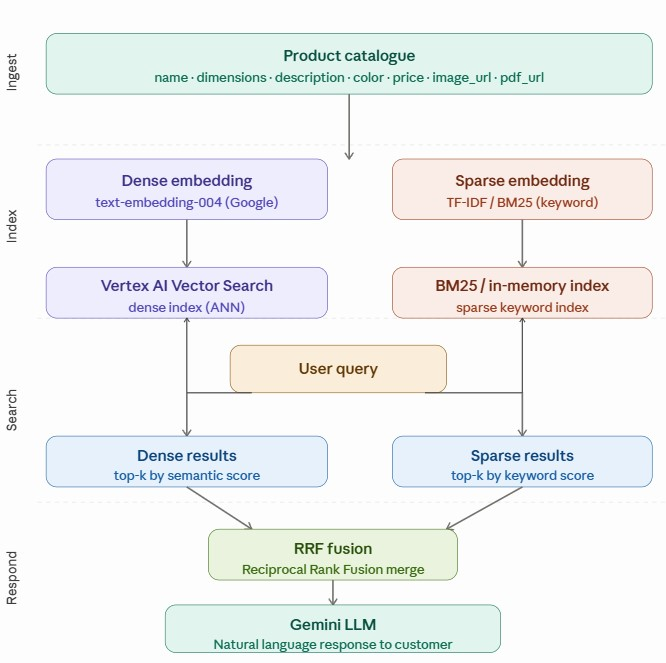

In [ ]:
pip install google-cloud-aiplatform vertexai scikit-learn numpy

## Module 1 — Product Catalogue 

This defines your data model. Each sofa is a Python dataclass — a clean, typed container. The to_text() method creates one combined string from all fields, which is what gets embedded.

In [ ]:
# catalogue.py
from dataclasses import dataclass
import pdfplumber
import requests
from io import BytesIO

@dataclass
class Sofa:
    id: str
    name: str
    description: str
    color: str
    dimensions: str   # e.g. "220cm W x 90cm D x 85cm H"
    price: float
    image_url: str
    pdf_url: str
    

    def extract_pdf_text(pdf_url: str, max_chars: int = 500) -> str:
    """
    Fetches a PDF from a URL and extracts its text content.
    We cap at 500 chars to keep the embedding input reasonable
    — embedding models have a token limit (~2048 tokens).
    """
    try:
        response = requests.get(pdf_url, timeout=10)
        with pdfplumber.open(BytesIO(response.content)) as pdf:
            full_text = " ".join(
                page.extract_text() for page in pdf.pages
                if page.extract_text()
            )
        return full_text[:max_chars]
    except Exception as e:
        print(f"Could not extract PDF: {e}")
        return ""

        # Updated to_text() — now includes PDF content
    def to_text(self) -> str:
        pdf_content = extract_pdf_text(self.pdf_url)
        base = (
            f"Name: {self.name}. "
            f"Description: {self.description}. "
            f"Color: {self.color}. "
            f"Dimensions: {self.dimensions}. "
            f"Price: INR {self.price}."
        )
        if pdf_content:
            base += f" Specs: {pdf_content}"
        return base

# Sample catalogue — replace with your real DB fetch
SAMPLE_CATALOGUE = [
    Sofa(
        id="sofa_001",
        name="Oslo 3-Seater Sofa",
        description="A minimalist Scandinavian-style sofa with solid oak legs and high-density foam cushions.",
        color="Charcoal Grey",
        dimensions="220cm W x 90cm D x 85cm H",
        price=45000,
        image_url="https://cdn.example.com/images/oslo_3seater.jpg",
        pdf_url="https://cdn.example.com/docs/oslo_3seater_spec.pdf",
    ),
    Sofa(
        id="sofa_002",
        name="Osaka L-Shape Sectional",
        description="A spacious L-shaped sectional sofa with deep seating, perfect for large living rooms.",
        color="Beige",
        dimensions="280cm W x 200cm D x 80cm H",
        price=78000,
        image_url="https://cdn.example.com/images/osaka_lshape.jpg",
        pdf_url="https://cdn.example.com/docs/osaka_lshape_spec.pdf",
    ),
    Sofa(
        id="sofa_003",
        name="Venice Chesterfield 2-Seater",
        description="Classic button-tufted Chesterfield sofa with rolled arms, upholstered in genuine leather.",
        color="Cognac Brown",
        dimensions="180cm W x 85cm D x 90cm H",
        price=62000,
        image_url="https://cdn.example.com/images/venice_chesterfield.jpg",
        pdf_url="https://cdn.example.com/docs/venice_spec.pdf",
    ),
]

## Module 2 — Dense Embedding 

This calls Google's text-embedding-004 model via Vertex AI to convert a text string into a 768-dimension vector. This vector captures meaning — similar sofas will have vectors that are geometrically close to each other in vector space.

In [ ]:
# embedder.py
import vertexai
from vertexai.language_models import TextEmbeddingModel

# Initialise Vertex AI once — reuse across calls
vertexai.init(project="YOUR_GCP_PROJECT_ID", location="us-central1")

_model = TextEmbeddingModel.from_pretrained("text-embedding-004")


def get_dense_embedding(text: str) -> list[float]:
    """
    Sends text to Google's text-embedding-004 model.
    Returns a list of 768 floats — the dense vector.

    'Dense' means every dimension has a value.
    Captures semantic meaning, so "comfy sofa" and
    "comfortable couch" will return similar vectors.
    """
    embeddings = _model.get_embeddings([text])
    return embeddings[0].values  # list of 768 floats

In [4]:
# the above code doesnt embed image which was provides as a URI - for those, we need to handle them separetely

In [ ]:
# In embedder.py — add a multimodal embedding option
# THIS IS ADDED AS A PATCH - NOT INCLUDED IN THE FINAL EMBEDDING
from vertexai.vision_models import MultiModalEmbeddingModel
import requests

_mm_model = MultiModalEmbeddingModel.from_pretrained("multimodalembedding@001")

def get_image_embedding(image_url: str) -> list[float]:
    """
    Fetches an image and returns its embedding vector (1408 dims).
    NOTE: this is a DIFFERENT vector space from text-embedding-004 (768 dims).
    You'd need a separate Vertex AI index for these,
    or use multimodalembedding for BOTH text and image
    so they share the same space.
    """
    image_bytes = requests.get(image_url).content
    from vertexai.vision_models import Image
    image = Image(image_bytes)
    result = _mm_model.get_embeddings(image=image)
    return result.image_embedding

## Module 3 — Sparse Embedding

This builds a TF-IDF sparse vectoriser for keyword search. Unlike dense vectors, sparse vectors are mostly zeros — only the words that appear get non-zero values. This is great for exact keyword matches like "chesterfield" or "L-shape".

In [ ]:
# sparse_embedder.py
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

class SparseEmbedder:
    """
    Builds a TF-IDF vocabulary from the product catalogue.
    TF-IDF = Term Frequency × Inverse Document Frequency.

    'Sparse' means most values are 0 — only present words
    get non-zero scores. Great for exact keyword matching.

    Steps:
      1. fit()  — learn vocabulary from all product texts
      2. transform() — convert any text to a sparse vector
    """

    def __init__(self):
        self.vectorizer = TfidfVectorizer(
            ngram_range=(1, 2),   # single words + word pairs
            max_features=10000,   # cap vocabulary size
            sublinear_tf=True,    # log-scale term frequency
        )
        self.is_fitted = False

    def fit(self, texts: list[str]):
        """
        Learn the vocabulary from all product descriptions.
        Must be called once before transform().
        """
        self.vectorizer.fit(texts)
        self.is_fitted = True
        print(f"Sparse vocab size: {len(self.vectorizer.vocabulary_)}")

    def transform(self, text: str) -> dict[int, float]:
        """
        Converts a text string into a sparse vector.
        Returns a dict of {dimension_index: score}
        so only non-zero values are stored.
        """
        if not self.is_fitted:
            raise RuntimeError("Call fit() before transform()")
        vec = self.vectorizer.transform([text])
        # Convert scipy sparse matrix to dict of non-zero entries
        cx = vec.tocoo()
        return {int(col): float(val) for col, val in zip(cx.col, cx.data)}

## Module 4 — Vertex AI Indexing

This creates the Vertex AI Vector Search index and upserts (inserts or updates) all product vectors into it. Think of this as building the "search engine" — you do this once when you set up or update your catalogue.

In [ ]:
# indexer.py
import json
import os
from google.cloud import aiplatform
from catalogue import Sofa, SAMPLE_CATALOGUE
from embedder import get_dense_embedding
from sparse_embedder import SparseEmbedder

# --- CONFIG ---
PROJECT_ID  = "YOUR_GCP_PROJECT_ID"
REGION      = "us-central1"
INDEX_NAME  = "sofa_search_index"
BUCKET_NAME = "YOUR_GCS_BUCKET"   # needed to upload vectors for batch upsert

aiplatform.init(project=PROJECT_ID, location=REGION)


def build_index_data(
    products: list[Sofa],
    sparse_embedder: SparseEmbedder,
) -> list[dict]:
    """
    For every product, creates a record containing:
      - id          : unique product identifier
      - dense vector: 768-float semantic embedding
      - sparse dict : keyword TF-IDF weights
      - metadata    : name, price, image/PDF URLs (returned with results)

    This list is what gets uploaded to Vertex AI.
    """
    records = []
    for product in products:
        text = product.to_text()
        dense_vec  = get_dense_embedding(text)
        sparse_vec = sparse_embedder.transform(text)

        records.append({
            "id": product.id,
            "embedding": dense_vec,
            "sparse_embedding": {
                "values": list(sparse_vec.values()),
                "dimensions": list(sparse_vec.keys()),
            },
            "restricts": [],          # optional Vertex AI filters
            "crowding_tag": "",
            "numeric_restricts": [],
            # Store metadata so search results carry product info
            "metadata": {
                "name":      product.name,
                "color":     product.color,
                "price":     product.price,
                "image_url": product.image_url,
                "pdf_url":   product.pdf_url,
            },
        })
        print(f"  Embedded: {product.name}")
    return records


def save_to_jsonl(records: list[dict], filepath: str):
    """
    Vertex AI expects data in JSONL format (one JSON object per line).
    Saves the records to a local file before uploading to GCS.
    """
    with open(filepath, "w") as f:
        for rec in records:
            f.write(json.dumps(rec) + "\n")
    print(f"Saved {len(records)} records to {filepath}")


def create_or_update_index(jsonl_gcs_uri: str) -> aiplatform.MatchingEngineIndex:
    """
    Creates a new Vertex AI Vector Search index (or updates existing).
    The index uses cosine distance for semantic similarity.

    IMPORTANT: Creating an index takes ~30–60 minutes on GCP.
    This is a one-time (or periodic) operation — not per search.
    """
    index = aiplatform.MatchingEngineIndex.create_tree_ah_index(
        display_name=INDEX_NAME,
        contents_delta_uri=jsonl_gcs_uri,
        dimensions=768,                   # must match embedding model output
        approximate_neighbors_count=10,
        distance_measure_type="COSINE_DISTANCE",
        description="Sofa product search index",
    )
    print(f"Index created: {index.resource_name}")
    return index


# --- MAIN: run this once to build your index ---
if __name__ == "__main__":
    sparse_embedder = SparseEmbedder()
    all_texts = [p.to_text() for p in SAMPLE_CATALOGUE]
    sparse_embedder.fit(all_texts)

    print("Building embeddings...")
    records = build_index_data(SAMPLE_CATALOGUE, sparse_embedder)

    save_to_jsonl(records, "product_vectors.jsonl")
    # Upload product_vectors.jsonl to GCS manually, then:
    # gcs_uri = f"gs://{BUCKET_NAME}/product_vectors.jsonl"
    # create_or_update_index(gcs_uri)

## Module 5 — Hybrid Search

This is the core search logic. It takes a user query, embeds it both ways (dense + sparse), queries both indexes in parallel, then uses Reciprocal Rank Fusion (RRF) to merge the two ranked lists into one unified ranking.

In [ ]:
# searcher.py
from dataclasses import dataclass
from google.cloud import aiplatform
from embedder import get_dense_embedding
from sparse_embedder import SparseEmbedder

# --- CONFIG ---
PROJECT_ID       = "YOUR_GCP_PROJECT_ID"
REGION           = "us-central1"
INDEX_ENDPOINT_ID = "YOUR_INDEX_ENDPOINT_ID"   # from GCP console after deployment
TOP_K            = 5      # number of results to retrieve per search type
RRF_K            = 60     # RRF constant — higher = less weight to top ranks


@dataclass
class SearchResult:
    """A single product result with its relevance score."""
    product_id: str
    name: str
    price: float
    image_url: str
    pdf_url: str
    rrf_score: float   # final fused score — higher is more relevant


def reciprocal_rank_fusion(
    dense_results: list[dict],
    sparse_results: list[dict],
    k: int = RRF_K,
) -> list[tuple[str, float]]:
    """
    RRF merges two ranked lists into one.

    Formula: score(doc) = sum over each list of 1 / (k + rank)
      - rank 1 (best)  → 1 / (60+1) = 0.0164
      - rank 5         → 1 / (60+5) = 0.0154
      - rank 10        → 1 / (60+10)= 0.0143

    A product appearing at rank 1 in BOTH lists scores highest.
    A product appearing at rank 1 in only one list still scores well.
    Products missing from one list simply get 0 contribution from it.

    Returns: list of (product_id, fused_score) sorted best first.
    """
    scores: dict[str, float] = {}

    # Contribute from dense ranking
    for rank, item in enumerate(dense_results, start=1):
        pid = item["id"]
        scores[pid] = scores.get(pid, 0.0) + 1.0 / (k + rank)

    # Contribute from sparse ranking
    for rank, item in enumerate(sparse_results, start=1):
        pid = item["id"]
        scores[pid] = scores.get(pid, 0.0) + 1.0 / (k + rank)

    # Sort by descending fused score
    return sorted(scores.items(), key=lambda x: x[1], reverse=True)


def search_dense(query_embedding: list[float], top_k: int = TOP_K) -> list[dict]:
    """
    Queries Vertex AI Vector Search with the dense (semantic) embedding.
    Returns nearest neighbours by cosine similarity.
    """
    index_endpoint = aiplatform.MatchingEngineIndexEndpoint(
        index_endpoint_name=INDEX_ENDPOINT_ID
    )
    response = index_endpoint.find_neighbors(
        deployed_index_id="sofa_index_deployed",
        queries=[query_embedding],
        num_neighbors=top_k,
    )
    results = []
    for neighbor in response[0]:
        results.append({
            "id":       neighbor.id,
            "distance": neighbor.distance,
        })
    return results


def search_sparse(
    query_sparse: dict[int, float],
    all_products_sparse: dict[str, dict[int, float]],
    top_k: int = TOP_K,
) -> list[dict]:
    """
    Dot-product keyword search using TF-IDF sparse vectors.
    Scores each product by how many query words it contains
    and how important those words are.

    In production you'd replace this with a proper BM25 index
    (rank_bm25 library or Elasticsearch). For clarity we use
    an in-memory dot product here.
    """
    import numpy as np

    scores = {}
    for product_id, product_vec in all_products_sparse.items():
        # Dot product between query sparse vector and product sparse vector
        score = sum(
            query_sparse.get(dim, 0.0) * weight
            for dim, weight in product_vec.items()
        )
        scores[product_id] = score

    # Return top-k sorted by score
    sorted_items = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [{"id": pid, "score": score} for pid, score in sorted_items[:top_k]]


def hybrid_search(
    query: str,
    sparse_embedder: SparseEmbedder,
    all_products_sparse: dict[str, dict[int, float]],
    product_metadata: dict[str, dict],
) -> list[SearchResult]:
    """
    Full hybrid search pipeline:
      1. Embed the query (dense + sparse)
      2. Search both indexes
      3. Fuse results with RRF
      4. Return enriched SearchResult objects
    """
    print(f"\nSearching for: '{query}'")

    # Step 1 — embed query both ways
    dense_vec  = get_dense_embedding(query)
    sparse_vec = sparse_embedder.transform(query)

    # Step 2 — search both indexes
    dense_hits  = search_dense(dense_vec)
    sparse_hits = search_sparse(sparse_vec, all_products_sparse)

    # Step 3 — fuse with RRF
    fused = reciprocal_rank_fusion(dense_hits, sparse_hits)

    # Step 4 — enrich with metadata
    results = []
    for product_id, rrf_score in fused[:TOP_K]:
        meta = product_metadata.get(product_id, {})
        results.append(SearchResult(
            product_id = product_id,
            name       = meta.get("name", "Unknown"),
            price      = meta.get("price", 0),
            image_url  = meta.get("image_url", ""),
            pdf_url    = meta.get("pdf_url", ""),
            rrf_score  = rrf_score,
        ))

    return results

## Module 6 — Gemini LLM Response

This takes the search results and the original query, and asks Gemini to write a natural, helpful product recommendation reply. The search results are passed as context — Gemini only synthesises, it doesn't retrieve.

In [ ]:
# responder.py
import vertexai
from vertexai.generative_models import GenerativeModel
from searcher import SearchResult

vertexai.init(project="YOUR_GCP_PROJECT_ID", location="us-central1")

_gemini = GenerativeModel("gemini-1.5-flash")


def format_results_for_prompt(results: list[SearchResult]) -> str:
    """
    Converts search results into a readable block for the LLM prompt.
    We include name, price, and URLs so Gemini can reference them.
    """
    lines = []
    for i, r in enumerate(results, start=1):
        lines.append(
            f"{i}. {r.name} — INR {r.price:,.0f}\n"
            f"   Image: {r.image_url}\n"
            f"   Spec PDF: {r.pdf_url}"
        )
    return "\n".join(lines)


def generate_response(query: str, results: list[SearchResult]) -> str:
    """
    Sends the user query + retrieved products to Gemini.
    Gemini generates a natural language recommendation response.

    The prompt structure (system role + context + question) is called
    Retrieval-Augmented Generation (RAG). The model uses ONLY the
    provided context — it does not hallucinate product details.
    """
    context = format_results_for_prompt(results)

    prompt = f"""You are a helpful furniture sales assistant for a premium sofa brand.
A customer has asked: "{query}"

Based on the following products from our catalogue, recommend the most suitable options.
Be warm, concise, and mention price and where they can view images or download spec sheets.

AVAILABLE PRODUCTS:
{context}

Your response:"""

    response = _gemini.generate_content(prompt)
    return response.text

## Module 7 — Main Pipeline

This ties everything together into one end-to-end flow you can run.

In [ ]:
# main.py
from catalogue import SAMPLE_CATALOGUE
from sparse_embedder import SparseEmbedder
from searcher import hybrid_search
from responder import generate_response


def build_sparse_index(products, sparse_embedder):
    """
    Pre-builds and caches the sparse (TF-IDF) vectors for all products.
    Returns a dict of {product_id: sparse_vector}.
    In production, persist this to disk or a cache layer.
    """
    all_texts = [p.to_text() for p in products]
    sparse_embedder.fit(all_texts)

    return {
        p.id: sparse_embedder.transform(p.to_text())
        for p in products
    }


def build_metadata_lookup(products):
    """
    Creates a quick-lookup dict of {product_id: metadata_dict}.
    Used to enrich search results after RRF fusion.
    """
    return {
        p.id: {
            "name":      p.name,
            "price":     p.price,
            "image_url": p.image_url,
            "pdf_url":   p.pdf_url,
        }
        for p in products
    }


def run_search(user_query: str):
    """
    End-to-end: takes a raw customer query string,
    runs hybrid search, feeds results to Gemini,
    and prints the natural language response.
    """
    # 1. Initialise (do once; cache in production)
    sparse_embedder = SparseEmbedder()
    all_products_sparse = build_sparse_index(SAMPLE_CATALOGUE, sparse_embedder)
    product_metadata    = build_metadata_lookup(SAMPLE_CATALOGUE)

    # 2. Hybrid search
    results = hybrid_search(
        query               = user_query,
        sparse_embedder     = sparse_embedder,
        all_products_sparse = all_products_sparse,
        product_metadata    = product_metadata,
    )

    # 3. Print ranked results
    print("\n--- TOP RESULTS ---")
    for r in results:
        print(f"  [{r.rrf_score:.4f}] {r.name}  INR {r.price:,.0f}")

    # 4. Generate LLM response
    print("\n--- GEMINI RESPONSE ---")
    reply = generate_response(user_query, results)
    print(reply)
    return reply


# Entry point
if __name__ == "__main__":
    run_search("I need a large beige sofa for my living room, budget under 1 lakh")